# 군집화 실습 — 고객 세그먼트

**데이터** `customers.csv` (고객 2,000명)

이 노트북은 **강의 진도에 맞춰 네 번 나눠서** 진행합니다.

| | 강의에서 여기까지 오면 | 실습 | 분 |
|---|---|---|---|
| **실습 1** | `2-4 차원 축소` | 스케일링을 안 하면 무슨 일이 | 4 |
| **실습 2** | `3-1 계층적 군집화` | 손으로 구한 답을 코드로 대조 | 5 |
| **실습 3** | `3-5 어떤 알고리즘을 고를까` | 알고리즘 4종을 같은 데이터에 | 5 |
| **실습 4** | `4-3 Dunn Index` | k 고르기 → 해석 → 되돌아가기 | 8 |

> 읽으면서 셀을 순서대로 실행하시면 됩니다. **직접 채우는 칸은 딱 두 군데**(실습 4)뿐이에요.

## 0. 준비 — 맨 처음 한 번만 실행

In [ ]:
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 설정 (OS 자동 감지: Mac → AppleGothic, Windows → Malgun Gothic, 그 외 → NanumGothic)
plt.rcParams['font.family'] = {'Darwin': 'AppleGothic', 'Windows': 'Malgun Gothic'}.get(platform.system(), 'NanumGothic')
plt.rcParams['axes.unicode_minus'] = False    # 마이너스 기호 깨짐 방지

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

import warnings; warnings.filterwarnings('ignore')

df = pd.read_csv('customers.csv')
X_raw = df.drop(columns='customer_id')     # 군집화에 쓸 6개 피처

# 군집별 평균을 보기 좋게 뽑아주는 함수 (계속 씁니다)
def profile(labels):
    t = X_raw.copy(); t['군집'] = labels
    return t.groupby('군집').agg(
        인원=('age','size'), 나이=('age','mean'), 연소득=('annual_income','mean'),
        소비성향=('spending_score','mean'), 방문=('visit_freq','mean'),
        장바구니=('avg_cart','mean'), 가입기간=('membership_years','mean'),
    ).round(0)

print(f'고객 {len(df)}명 · 피처 {X_raw.shape[1]}개')
df.head()

---
# 실습 1 — 스케일링을 안 하면?
<span style="color:#888">강의 `2-4 차원 축소`까지 듣고 오시면 됩니다</span>

강의에서 **거리 기반 알고리즘은 스케일링이 먼저**라고 했죠.
왜 그런지, **일부러 안 하고** 한 번 돌려보겠습니다.

In [6]:
# 아무 처리 없이 원본 그대로 k-means
labels_raw = KMeans(n_clusters=4, n_init=10, random_state=42).fit_predict(X_raw)
profile(labels_raw)

,인원,나이,연소득,소비성향,방문,장바구니,가입기간
군집,,,,,,,
0,1021,41.0,4487.0,53.0,12.0,54130.0,4.0
1,135,39.0,9889.0,80.0,19.0,392790.0,7.0
2,703,42.0,10879.0,51.0,9.0,192989.0,6.0
3,141,38.0,9722.0,83.0,19.0,553744.0,7.0


### 장바구니 금액으로만 나뉘었습니다

군집별 **장바구니** 평균을 보세요. `5.4만 → 19.3만 → 39.3만 → 55.4만` 으로 깔끔하게 층이 집니다.

그런데 **소비성향**은 `53 / 51 / 80 / 83`, **나이**는 `41 / 42 / 39 / 38` 로 거의 구분이 안 됩니다.
6개 피처로 나눈 게 아니라 **장바구니 하나로 나눈 것**이나 마찬가지예요.

왜 이렇게 됐을까요? 각 피처의 **표준편차**를 보면 바로 나옵니다.

In [7]:
X_raw.std().round(1).to_frame('표준편차')

,표준편차
age,12.5
annual_income,3617.6
spending_score,26.7
visit_freq,9.2
avg_cart,147830.6
membership_years,3.3


### 👉 단위가 큰 피처 하나가 거리를 통째로 먹습니다

`avg_cart`의 표준편차는 **147,831**, `membership_years`는 **3.3** 입니다. **약 4만 5천 배** 차이예요.

유클리디안 거리는 각 축의 차이를 제곱해서 더합니다.
그러니 장바구니에서 10만 원 차이가 나면, 나머지 5개 피처가 아무리 달라도 **묻혀버립니다.**

그래서 **평균 0, 표준편차 1**로 맞춰주는 게 스케일링입니다.

In [8]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)          # ⬅️ 앞으로 계속 이 X를 씁니다

labels_scaled = KMeans(n_clusters=4, n_init=10, random_state=42).fit_predict(X)
profile(labels_scaled)

,인원,나이,연소득,소비성향,방문,장바구니,가입기간
군집,,,,,,,
0,558,38.0,9702.0,81.0,18.0,331707.0,7.0
1,441,58.0,5038.0,25.0,2.0,58192.0,6.0
2,479,45.0,11753.0,32.0,3.0,182022.0,5.0
3,522,27.0,3200.0,78.0,21.0,46165.0,2.0


### 이제 6개 피처가 다 일을 합니다

- **27세 · 소득 3,200 · 소비성향 78 · 방문 21회** — 돈은 없는데 자주 오는 젊은 층
- **58세 · 소득 5,038 · 소비성향 25 · 방문 2회** — 거의 안 오는 층
- **45세 · 소득 11,753 · 소비성향 32 · 방문 3회** — 소득은 최고인데 안 씀
- **38세 · 소득 9,702 · 소비성향 81 · 방문 18회** — 소득도 소비도 높은 층

나이·소득·소비성향·방문이 **전부 군집을 가르는 데 쓰였습니다.** 스케일링 전과 비교해 보세요.

### 이제 차원을 줄여볼까요

강의 `2-4`에서 본 **PCA**입니다. 피처가 6개인데, 정말 줄여야 할까요?
일단 **몇 개까지 줄일 수 있는지**부터 봅니다.

In [9]:
from sklearn.decomposition import PCA

pca = PCA().fit(X)                       # n_components 없이 → 주성분 전부 뽑기
ratio = pca.explained_variance_ratio_

pd.DataFrame({
    '주성분': [f'PC{i+1}' for i in range(len(ratio))],
    '설명 분산': ratio.round(3),
    '누적': ratio.cumsum().round(3),
})

,주성분,설명 분산,누적
0,PC1,0.465,0.465
1,PC2,0.309,0.773
2,PC3,0.112,0.886
3,PC4,0.065,0.951
4,PC5,0.032,0.983
5,PC6,0.017,1.000


### 2개면 77.3%, 3개는 88.6%

- **PC1 + PC2 = 0.773** → 2차원으로 줄여도 정보의 77.3% 가 남습니다
- **3개까지 = 0.886** → 90%에 **아슬아슬하게 못 미칩니다**
- **4개까지 = 0.951**

여기서 판단이 갈립니다. **90%를 고집하면 4개**를 써야 하는데, 4차원은 그림으로 못 그립니다.
`n_components` 에 비율을 넣으면 알아서 골라줍니다.

In [10]:
print('90% 기준 →', PCA(n_components=0.9).fit(X).n_components_, '개')
print('80% 기준 →', PCA(n_components=0.8).fit(X).n_components_, '개')

90% 기준 → 4 개
80% 기준 → 3 개


### 그런데 6개는 애초에 줄여야 할 만큼 많지 않습니다

강의에서 **차원의 저주**를 배웠죠. 그건 피처가 수십~수백 개일 때 이야기입니다.
**6개는 그냥 써도 됩니다.**

그럼 여기서 PCA를 왜 쓸까요? → **그림으로 보여주려고** 씁니다.
마케팅팀에게 결과를 설명해야 하는데, **6차원은 그릴 수가 없거든요.**

차원 축소는 **성능**만이 아니라 **소통**을 위한 것이기도 합니다.

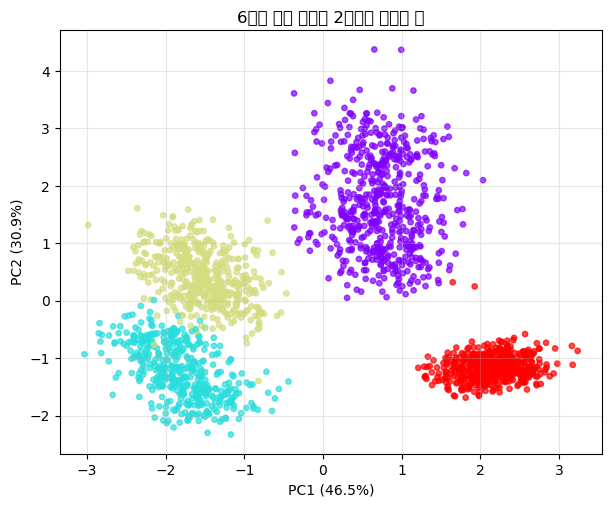

In [11]:
X_pca2 = PCA(n_components=2, random_state=42).fit_transform(X)

plt.figure(figsize=(7, 5.5))
plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=labels_scaled, cmap='rainbow', s=15, alpha=.7)
plt.xlabel(f'PC1 ({ratio[0]*100:.1f}%)'); plt.ylabel(f'PC2 ({ratio[1]*100:.1f}%)')
plt.title('6차원 군집 결과를 2차원에 그려본 것'); plt.grid(alpha=.3); plt.show()

### 그럼 군집화도 2차원으로 하면 안 되나요?

**해도 되긴 합니다.** 다만 원칙은 **군집화는 원본으로, 그림만 축소**입니다. 확인해 봅시다.

In [12]:
lab_6d = KMeans(n_clusters=4, n_init=10, random_state=42).fit_predict(X)        # 6차원으로 군집화
lab_2d = KMeans(n_clusters=4, n_init=10, random_state=42).fit_predict(X_pca2)   # 2차원으로 군집화

print(f"6차원으로 군집화 → 실루엣 {silhouette_score(X, lab_6d):.3f}")
print(f"2차원으로 군집화 → 실루엣 {silhouette_score(X, lab_2d):.3f}   (둘 다 6차원 기준으로 측정)")
print(f"두 방식이 같은 군집을 준 고객 비율: {(pd.crosstab(lab_6d, lab_2d).max(axis=1).sum()/len(lab_6d))*100:.1f}%")

6차원으로 군집화 → 실루엣 0.481
2차원으로 군집화 → 실루엣 0.472   (둘 다 6차원 기준으로 측정)
두 방식이 같은 군집을 준 고객 비율: 99.0%


### 거의 같지만, 미세하게 손해입니다

`0.481` vs `0.472` — **99%의 고객이 같은 군집**을 받았습니다. 이 데이터에서는 어느 쪽이든 큰 차이가 없어요.

하지만 2차원으로 줄이는 순간 **정보의 22.7%를 버리고** 시작합니다. 굳이 버릴 이유가 없죠.

👉 **군집화는 원본(6차원 스케일링본)으로, 그림 그릴 때만 2차원으로.** 이게 기본입니다.

> ✅ **실습 1 끝** — 강의로 돌아갑니다.

---
# 실습 2 — 손으로 구한 답을 코드로 대조
<span style="color:#888">강의 `3-1 계층적 군집화`까지 듣고 오시면 됩니다</span>

강의에서 점 5개(A\~E)를 **손으로** 병합해봤죠. 단일 연결법으로 `2 → 3 → 6 → 18` 이 나왔습니다.
**정말 맞는지 코드로 확인**해 봅시다.

In [13]:
# 강의에서 쓴 거리 행렬 그대로
labels5 = ['A','B','C','D','E']
D = np.array([
    [ 0,  2, 20, 18, 22],
    [ 2,  0, 21, 19, 23],
    [20, 21,  0,  3,  7],
    [18, 19,  3,  0,  6],
    [22, 23,  7,  6,  0],
], dtype=float)

for method in ['single', 'complete', 'average']:
    Z = linkage(squareform(D), method=method)
    print(f"{method:9s} 병합 높이: {[round(z[2],1) for z in Z]}")

single    병합 높이: [np.float64(2.0), np.float64(3.0), np.float64(6.0), np.float64(18.0)]
complete  병합 높이: [np.float64(2.0), np.float64(3.0), np.float64(7.0), np.float64(23.0)]
average   병합 높이: [np.float64(2.0), np.float64(3.0), np.float64(6.5), np.float64(20.5)]


### 손으로 구한 것과 같습니다

**단일 연결법** `2 → 3 → 6 → 18` — 강의에서 손으로 구한 그대로죠.

그리고 강의에서 막혔던 그 지점, **{C,D}와 E의 거리**를 보세요. 연결법마다 답이 다릅니다.

| 연결법 | {C,D}↔E | 전체 병합 높이 |
|---|---|---|
| 단일 (min) | `min(7, 6)` = **6** | 2 → 3 → **6** → 18 |
| 완전 (max) | `max(7, 6)` = **7** | 2 → 3 → **7** → 23 |
| 평균 | `(7+6)/2` = **6.5** | 2 → 3 → **6.5** → 20.5 |

👉 **거리 행렬은 하나인데 덴드로그램은 셋입니다.** 연결법이 곧 선택이에요.

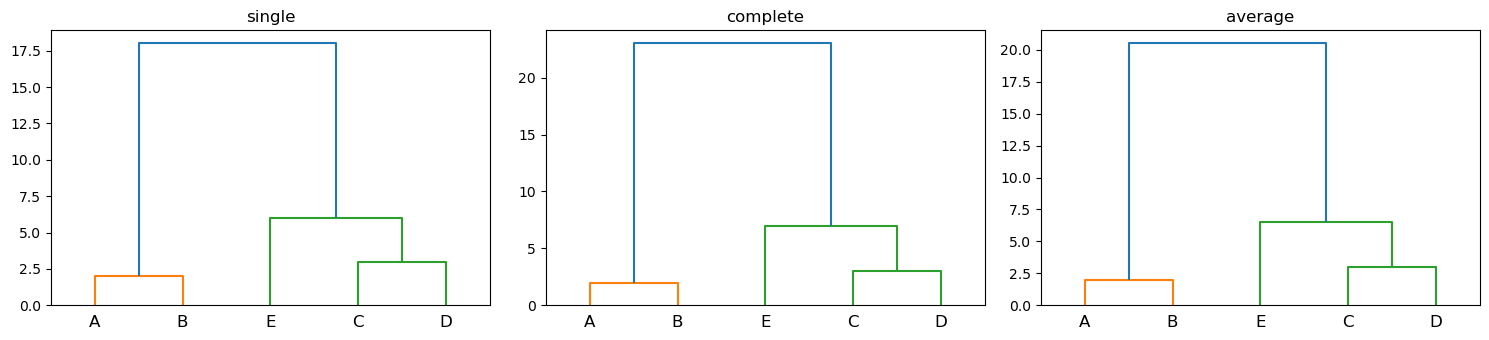

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, method in zip(axes, ['single', 'complete', 'average']):
    dendrogram(linkage(squareform(D), method=method), labels=labels5, ax=ax)
    ax.set_title(method)
plt.tight_layout(); plt.show()

### 실제 고객 데이터에서도 갈릴까?

점 5개가 아니라 **고객 2,000명**에 같은 네 가지 연결법을 적용해 봅니다.

In [15]:
rows = []
for method in ['ward', 'average', 'complete', 'single']:
    lab = AgglomerativeClustering(n_clusters=4, linkage=method).fit_predict(X)
    rows.append({'연결법': method,
                 '실루엣': round(silhouette_score(X, lab), 3),
                 '군집 크기': np.bincount(lab).tolist()})
pd.DataFrame(rows)

,연결법,실루엣,군집 크기
0,ward,0.481,"[560, 441, 520, 479]"
1,average,0.481,"[560, 479, 520, 441]"
2,complete,0.391,"[887, 440, 193, 480]"
3,single,0.380,"[560, 919, 1, 520]"


### `single`만 무너졌습니다

군집 크기를 보세요. **`single` 은 `[560, 919, 1, 520]`** — **혼자 있는 군집이 하나** 생겼습니다.
`complete` 도 `[887, 440, 193, 480]` 로 한쪽에 쏠렸고요.

단일 연결법은 **가장 가까운 한 쌍만 보고** 병합합니다.
그래서 점들이 띄엄띄엄 이어져 있으면 줄줄이 한 덩어리로 빨려 들어가고(**체인 효과**),
동떨어진 점 하나가 끝까지 안 붙어서 **1개짜리 군집**으로 남습니다.

👉 `ward` 와 `average` 가 0.481로 가장 안정적입니다. **보통 `ward` 를 기본값으로 씁니다.**

> ✅ **실습 2 끝** — 강의로 돌아갑니다.

---
# 실습 3 — 알고리즘 4종을 같은 데이터에
<span style="color:#888">강의 `3-5 어떤 알고리즘을 고를까`까지 듣고 오시면 됩니다</span>

지금까지 k-means · 계층적 · DBSCAN · GMM 네 가지를 배웠습니다.
**같은 데이터, 같은 군집 수(4개)** 로 나란히 놓고 비교해 봅시다.

In [16]:
models = {
    'k-means'     : KMeans(n_clusters=4, n_init=10, random_state=42),
    'GMM'         : GaussianMixture(n_components=4, random_state=42),
    '계층적 (ward)' : AgglomerativeClustering(n_clusters=4, linkage='ward'),
}

rows = []
for name, model in models.items():
    lab = model.fit_predict(X)
    rows.append({'알고리즘': name,
                 '실루엣': round(silhouette_score(X, lab), 3),
                 '군집 크기': sorted(np.bincount(lab).tolist(), reverse=True)})
pd.DataFrame(rows)

,알고리즘,실루엣,군집 크기
0,k-means,0.481,"[558, 522, 479, 441]"
1,GMM,0.481,"[560, 520, 480, 440]"
2,계층적 (ward),0.481,"[560, 520, 479, 441]"


### 셋 다 똑같습니다

실루엣이 **0.481로 동일**하고, 군집 크기도 `[560, 522, 479, 441]` 근처로 거의 같습니다.

이건 이 데이터가 **동글동글하게 잘 뭉쳐 있어서** 그렇습니다.
군집이 명확하면 알고리즘을 뭘 쓰든 비슷한 답이 나와요.

👉 **알고리즘 선택이 항상 중요한 건 아닙니다.** 데이터 모양이 애매할 때 비로소 갈립니다.

### DBSCAN은 왜 뺐을까요

DBSCAN은 **군집 수를 정해줄 수가 없습니다.** `eps` 를 바꿔가며 무슨 일이 생기는지 봅시다.

In [17]:
rows = []
for eps in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2]:
    lab = DBSCAN(eps=eps, min_samples=10).fit_predict(X)
    n_cluster = len(set(lab)) - (1 if -1 in lab else 0)
    n_noise = (lab == -1).sum()
    rows.append({'eps': eps, '군집 수': n_cluster, '노이즈': n_noise,
                 '노이즈 비율(%)': round(n_noise / len(lab) * 100, 1)})
pd.DataFrame(rows)

,eps,군집 수,노이즈,노이즈 비율(%)
0,0.5,3,886,44.3
1,0.6,6,450,22.5
2,0.7,6,202,10.1
3,0.8,3,62,3.1
4,0.9,3,13,0.6
5,1.0,3,5,0.2
6,1.2,2,1,0.0


### 군집 4개가 나오는 `eps` 가 없습니다

- `eps=0.5` → 군집 3개인데 **노이즈가 886명 (44.3%)**
- `eps=0.6~0.7` → 군집이 **6개**로 쪼개짐
- `eps=0.9~1.0` → 노이즈는 거의 없지만 군집은 **3개**

`eps` 를 아무리 조정해도 **4개가 안 나옵니다.** 노이즈를 줄이면 군집이 뭉치고, 군집을 늘리면 노이즈가 폭증해요.

그리고 더 중요한 건 **목적**입니다.
마케팅팀의 요청은 *"전 고객을 그룹으로 나눠달라"* 였습니다. `eps=0.5` 를 쓰면 **886명이 `-1`(이상치)** 로 빠져서
**프로모션을 못 받는 고객**이 생깁니다.

👉 알고리즘은 **데이터 모양**만이 아니라 **비즈니스 목적**이 정합니다. 그래서 이 문제에서 DBSCAN은 후보에서 뺍니다.

> ✅ **실습 3 끝** — 강의로 돌아갑니다.

---
# 실습 4 — k 고르기 → 해석 → 되돌아가기
<span style="color:#888">강의 `4-3 Dunn Index`까지 듣고 오시면 됩니다</span>

이제 **군집을 몇 개로 나눌지** 정할 차례입니다. 실루엣 계수로 k를 훑어봅니다.

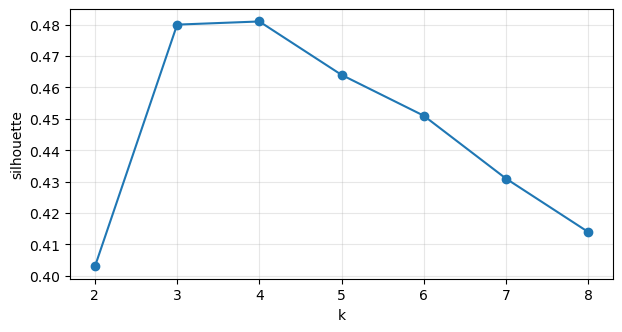

,k,평균 실루엣
0,2,0.403
1,3,0.480
2,4,0.481
3,5,0.464
4,6,0.451
5,7,0.431
6,8,0.414


In [18]:
rows = []
for k in range(2, 9):
    lab = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X)
    rows.append({'k': k, '평균 실루엣': round(silhouette_score(X, lab), 3)})
result = pd.DataFrame(rows)

plt.figure(figsize=(7, 3.5))
plt.plot(result['k'], result['평균 실루엣'], 'o-')
plt.xlabel('k'); plt.ylabel('silhouette'); plt.grid(alpha=.3); plt.show()
result

### k=3과 k=4가 사실상 동점입니다

`k=3` 은 **0.480**, `k=4` 는 **0.481**. 차이가 **0.001** 이에요.

이 정도 차이로는 **숫자가 답을 못 정해줍니다.** 그럼 무엇으로 정할까요?
👉 **군집을 열어서, 말이 되는 쪽을 고릅니다.**

In [19]:
print('===== k = 3 ====='); display(profile(KMeans(3, n_init=10, random_state=42).fit_predict(X)))
print('===== k = 4 ====='); display(profile(KMeans(4, n_init=10, random_state=42).fit_predict(X)))

===== k = 3 =====


,인원,나이,연소득,소비성향,방문,장바구니,가입기간
군집,,,,,,,
0,559,38.0,9706.0,81.0,18.0,331580.0,7.0
1,919,51.0,8530.0,29.0,2.0,122515.0,6.0
2,522,27.0,3200.0,78.0,21.0,46165.0,2.0


===== k = 4 =====


,인원,나이,연소득,소비성향,방문,장바구니,가입기간
군집,,,,,,,
0,558,38.0,9702.0,81.0,18.0,331707.0,7.0
1,441,58.0,5038.0,25.0,2.0,58192.0,6.0
2,479,45.0,11753.0,32.0,3.0,182022.0,5.0
3,522,27.0,3200.0,78.0,21.0,46165.0,2.0


### k=3에서는 **919명짜리 군집**이 문제입니다

`k=3` 의 가장 큰 군집(919명)을 보세요. **연소득 8,530 · 나이 51 · 방문 2회.**

이 군집이 `k=4` 에서는 **둘로 갈라집니다.**

| | 인원 | 연소득 | 소비성향 | 방문 | 정체 |
|---|---|---|---|---|---|
| 잠든 고소득 | 479 | **11,753** | 32 | 3회 | 돈은 있는데 안 씀 |
| 이탈 | 441 | **5,038** | 25 | 2회 | 여력도 의사도 없음 |

**연소득이 2배 이상 차이 나는 두 집단**이 `k=3` 에서는 한 그룹으로 묶여 있었던 겁니다.

이 둘에게 **같은 프로모션을 보내면 안 됩니다.**
앞쪽은 *"여력이 있으니 끌어올릴 여지"* 가 있고, 뒤쪽은 *"회수 비용이 더 큰"* 집단이거든요.

👉 **실루엣 0.001 차이가 마케팅에서는 전략이 갈리는 차이입니다.**

### ✏️ 직접 정하세요 (1/2)

위 비교를 근거로 **k를 정해서** 아래에 넣으세요.

In [ ]:
k =      # ⬅️ 여기에 숫자를 넣으세요

final_labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X)
print(f'k = {k} · 평균 실루엣 = {silhouette_score(X, final_labels):.3f}')
profile(final_labels)

k = 4 · 평균 실루엣 = 0.481


,인원,나이,연소득,소비성향,방문,장바구니,가입기간
군집,,,,,,,
0,558,38.0,9702.0,81.0,18.0,331707.0,7.0
1,441,58.0,5038.0,25.0,2.0,58192.0,6.0
2,479,45.0,11753.0,32.0,3.0,182022.0,5.0
3,522,27.0,3200.0,78.0,21.0,46165.0,2.0


### 이름을 붙여보세요

군집에 **이름을 붙일 수 없다면 잘못 나뉜 것**입니다.

| 군집 | 이름 | 어떤 프로모션? |
|---|---|---|
| 0 | | |
| 1 | | |
| 2 | | |
| 3 | | |

<details>
<summary>예시 (먼저 직접 붙여본 뒤에 펼치세요)</summary>

| 특징 | 이름 | 프로모션 |
|---|---|---|
| 27세 · 소득 낮음 · 소비성향 78 · 21회 방문 | 알뜰 단골 | 저가·묶음 상품 |
| 38세 · 소득 높음 · 소비성향 81 · 18회 방문 | 핵심 우량 | VIP 등급 · 리텐션 |
| 45세 · 소득 최고 · 소비성향 32 · 3회 방문 | **잠든 고소득** | **예산 집중** — 끌어올릴 여지가 가장 큼 |
| 58세 · 소득 낮음 · 소비성향 25 · 2회 방문 | 이탈 | 최소 투자 |

</details>

### 다시 1단계로 — 군집화는 한 바퀴로 안 끝납니다

강의 `1-3`에서 *"군집화는 반복이다"* 라고 했죠. 실제로 되돌아가 봅시다.

피처 6개를 전부 넣었지만, **모든 피처가 군집을 가르는 데 기여하는 건 아닙니다.**
어떤 피처는 군집마다 뚜렷하게 갈리고, 어떤 피처는 **어느 군집에 속하든 제각각**이에요.

아래 셀은 **각 피처를 군집이 얼마나 설명하는지**를 0\~1로 계산합니다.
1에 가까우면 군집마다 확실히 다르다는 뜻이고, 0에 가까우면 군집과 거의 무관하다는 뜻입니다.

In [21]:
Z = pd.DataFrame(X, columns=X_raw.columns)                      # 표준화된 값
Z['군집'] = KMeans(4, n_init=10, random_state=42).fit_predict(X)

print('군집이 각 피처를 얼마나 설명하는가   (0 = 전혀, 1 = 완전히)\n')
scores = {}
for col in X_raw.columns:
    grand   = Z[col].mean()
    between = sum(len(gv) * (gv[col].mean() - grand) ** 2 for _, gv in Z.groupby('군집'))
    total   = ((Z[col] - grand) ** 2).sum()
    scores[col] = between / total

for col, v in sorted(scores.items(), key=lambda x: -x[1]):
    print(f'  {col:<18} {v:.3f}   {"|" * int(v * 40)}')

군집이 각 피처를 얼마나 설명하는가   (0 = 전혀, 1 = 완전히)

  spending_score     0.921   ||||||||||||||||||||||||||||||||||||
  annual_income      0.906   ||||||||||||||||||||||||||||||||||||
  visit_freq         0.884   |||||||||||||||||||||||||||||||||||
  age                0.776   |||||||||||||||||||||||||||||||
  avg_cart           0.641   |||||||||||||||||||||||||
  membership_years   0.367   ||||||||||||||


### ✏️ 직접 정하세요 (2/2)

In [ ]:
drop_col = ''      # ⬅️ 뺄 피처 이름을 넣으세요 (예: 'age')

X_sub = StandardScaler().fit_transform(X_raw.drop(columns=drop_col))
lab_sub = KMeans(n_clusters=4, n_init=10, random_state=42).fit_predict(X_sub)

before = silhouette_score(X, KMeans(4, n_init=10, random_state=42).fit_predict(X))
after  = silhouette_score(X_sub, lab_sub)
print(f"피처 6개 전부       : {before:.3f}")
print(f"'{drop_col}' 뺀 뒤   : {after:.3f}   ({after-before:+.3f})")

피처 6개 전부       : 0.481
'membership_years' 뺀 뒤   : 0.567   (+0.086)


### `membership_years` 를 빼면 0.481 → **0.567**

위 표에서 `membership_years` 만 **0.367** 이었습니다. 나머지는 전부 **0.64 이상**이었죠.
다른 피처들에 비해 군집을 설명하는 정도가 가장 낮다는 뜻입니다.

프로필 표의 `가입기간` 을 보면 군집별 평균은 약 `7.2 / 6.0 / 5.5 / 2.0`년이고,
군집 내 표준편차는 각각 `2.9 / 3.4 / 2.7 / 1.2`년입니다. 전체 표준편차는 `3.3`년입니다.
특히 군집 0–2에서는 가입기간의 산포가 전체와 비슷하게 크지만, 군집 3은 짧은 가입기간의 고객이 비교적 뚜렷하게 모여 있습니다.

즉, 가입기간이 완전히 무관한 피처는 아니지만 **다른 피처보다 군집을 가르는 기여도가 낮았고**, 거리 계산에서는 잡음으로 작용했습니다.

빼고 나니 실루엣이 **0.086 올랐습니다.** 꽤 큰 폭이에요.

👉 그렇다고 **"쓸모없는 피처였다"** 는 아닙니다.
가입 기간은 *고객을 나누는 축*은 아니었지만, 나눈 **다음에** 각 그룹을 설명할 때는 여전히 쓸모가 있습니다.
**군집화에 넣을 피처**와 **해석에 쓸 피처**는 다를 수 있어요.

> ✅ **실습 4 끝**

---
<div style="padding:16px;border-radius:8px">

## 🔁 한 바퀴 돌았습니다

방금 여러분이 한 것이 강의 `1-3`의 **군집화 4단계** 그대로입니다.

| 단계 | 어디서 했나 | 무엇을 알았나 |
|---|---|---|
| **1️⃣ 피처 선택** | 실습 1 | 스케일링을 안 하면 **단위 큰 피처 하나가 다 먹는다** |
| **2️⃣ 알고리즘 선택** | 실습 2 · 3 | 연결법에 따라 **무너지기도** 한다 / 목적이 DBSCAN을 뺐다 |
| **3️⃣ 유효성 검증** | 실습 4 | 지표가 **k를 못 정해줄 때**가 있다 |
| **4️⃣ 결과 해석** | 실습 4 | 이름을 못 붙이면 **잘못 나뉜 것** |
| **🔁 다시 1️⃣로** | 실습 4 | 피처를 바꾸니 **0.481 → 0.567** |

**결과물은 군집 4개가 아니라, *"잠든 고소득 그룹에 예산을 쓰자"* 입니다.**

</div>

수고하셨습니다!